In [1]:

import multiprocessing

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from scipy.optimize import curve_fit
from scipy.stats import norm


/home/ritaferi/pymc-env/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.figsize": (5.8, 3.6),  # tipico per colonna singola
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

In [3]:
# ============================================================
# CONFIGURATION
# ============================================================
FILES = {
    "50d": {
        "path": "csv-files/zro2_white&green_ 50_days.csv",
        "time": 4279386,
        "calibration": {
            "a": 0.357304,
            "b": -0.295444,
            "c": 1.352297e-9,
        },
    },
    "30d": {
        "path": "csv-files/new_data.csv",
        "time": 2827661,
        "calibration": {
            "a": 0.4142675,
            "b": 2.78,
            "c": 8.4771e-7,
        },
    },
}




# peak 3

In [4]:
ENERGY_RANGE = (0, 3000)
BIN_WIDTH = 0.4

BACKGROUND_PEAKS = {
    "228Ac_755keV" : 755.31,
    "208Tl_766keV" : 766.84,
    "214_Bi" : 768.356,
    #"152Eu_778keV" : 609 , 
    "228Ac_794keV" : 794.95,

}


FIT_WINDOW = 5

SIGNAL = {
    "mu": 778.2,
    "roi": (748, 810),
}

SAMPLING_CONFIG = {
    "draws": 2000,
    "tune": 2000,
    "chains": 4,
    "target_accept": 0.95,
}


In [5]:
# ============================================================
# ENERGY RESOLUTION
# ============================================================
def sigma_fun(E):
    """
    Detector energy resolution model.
    Returns sigma in keV.
    """
    A = 3.68436e1
    B = 1.72714e4

    return (E * np.sqrt(A / E + B / E**2)) / 2.355 / 100
    


In [6]:

# ============================================================
# DATA LOADING
# ============================================================
def load_spectrum(file_path, calibration, energy_range=(0, 3000)):
    """
    Load raw spectrum and convert channels to energy.
    """

    data = pd.read_csv(file_path, header=None)
    spectrum = data[0].to_numpy(dtype=np.float64)

    channels = np.arange(len(spectrum))

    E = (
        channels * calibration["a"]
        + calibration["b"]
        + calibration["c"] * channels**2
    )

    mask = (E >= energy_range[0]) & (E <= energy_range[1])

    return E[mask], spectrum[mask]

In [7]:
# ============================================================
# HISTOGRAMMING
# ============================================================
def make_histogram(E, spectrum, bins):
    counts, edges = np.histogram(E, bins=bins, weights=spectrum)
    centers = 0.5 * (edges[1:] + edges[:-1])

    return centers, counts



In [8]:

# ============================================================
# GAUSSIAN MODEL
# ============================================================
def gaussian_plus_bg(E, mu, sigma, area, m, background, ):
    """
    Gaussian normalized to total area + flat background.
    """

    gaussian = (
        area
        / (sigma * np.sqrt(2 * np.pi))
        * np.exp(-0.5 * ((E - mu) / sigma) ** 2)
    )

    return gaussian + background + m*E


In [9]:
# ============================================================
# PEAK FITTING
# ============================================================
def fit_peak(E, counts, center, window=4, plot=True):
    """
    Fit a Gaussian peak + constant background.
    """

    mask = (E > center - window) & (E < center + window)

    E_roi = E[mask]
    counts_roi = counts[mask]

    sigma_guess = sigma_fun(center)

    p0 = [
        center,
        sigma_guess,
        np.sum(counts_roi),
        0,
        np.median(counts_roi),
    ]

    bounds = (
        [center - 1, 0.01, 0, - np.inf,0],
        [center + 1, 10, np.inf, np.inf,   np.inf],
    )

    popt, pcov = curve_fit(
        gaussian_plus_bg,
        E_roi,
        counts_roi,
        p0=p0,
        bounds=bounds,
        #sigma=np.sqrt(counts_roi),
        maxfev=10000,
    )

    perr = np.sqrt(np.diag(pcov))

    result = {
        "mu": popt[0],
        "sigma": popt[1],
        "N": popt[2],
        "M" : popt[3],
        "B": popt[4],
        "err_mu": perr[0],
        "err_sigma": perr[1],
        "err_N": perr[2],
        "err_M": perr[3],
        "err_B": perr[4],
    }

    if plot:
        fig, ax = plt.subplots(
            2,
            1,
            figsize=(7, 6),
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1]},
        )

        E_fit = np.linspace(E_roi.min(), E_roi.max(), 400)
        model_fit = gaussian_plus_bg(E_fit, *popt)

        ax[0].step(E_roi, counts_roi, where="mid", color="black", label="Data")
        ax[0].scatter(E_roi, counts_roi, color="black")
        ax[0].plot(E_fit, model_fit, color="red", lw=2, label="Fit")

        ax[0].set_ylabel(f"Counts / {E_roi[1]-E_roi[0]:.2f} keV")
        ax[0].set_title(f"Peak @ {center:.2f} keV")
        ax[0].legend()
        ax[0].grid(alpha=0.3)

        residuals = counts_roi - gaussian_plus_bg(E_roi, *popt)

        ax[1].scatter(E_roi, residuals, s=15)
        ax[1].axhline(0, color="red")
        ax[1].set_xlabel("Energy [keV]")
        ax[1].set_ylabel("Residuals")
        ax[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return result


In [10]:

# ============================================================
# BUILD TOTAL DATASET
# ============================================================
def build_total_spectrum(files_config, bins):
    all_histograms = []
    total_time = 0

    for key, cfg in files_config.items():
        E, spectrum = load_spectrum(
            cfg["path"],
            cfg["calibration"],
            ENERGY_RANGE,
        )

        E_centers, counts = make_histogram(E, spectrum, bins)

        all_histograms.append(counts)
        total_time += cfg["time"]

    total_counts = np.sum(all_histograms, axis=0)

    return E_centers, total_counts, total_time

In [11]:
# ============================================================
# MAIN DATA PREPARATION
# ============================================================
BINS = np.arange(ENERGY_RANGE[0], ENERGY_RANGE[1], BIN_WIDTH)

E_tot, Ntot, t_tot = build_total_spectrum(FILES, BINS)

print(
    f"Total counts = {np.sum(Ntot):.0f} "
    f"in {t_tot / (60 * 60 * 24):.1f} days"
)


Total counts = 18324 in 82.3 days


In [12]:
print(sigma_fun(np.array([795])))

[0.91627364]


In [42]:
def gaussian_plus_bg(E, mu, sigma, N, B):

    g = (
        N
        * np.exp(-(E - mu)**2 / (2 * sigma**2))
        / (sigma * np.sqrt(2 * np.pi))
    )

    return g + B


# ============================================================
# DOUBLE GAUSSIAN (COMMON SIGMA) + LINEAR BACKGROUND
# ============================================================

def double_gaussian_plus_bg(E, mu1, N1, mu2, N2, sigma,B):

    g1 = (
        N1
        * np.exp(-(E - mu1)**2 / (2 * sigma**2))
        / (sigma * np.sqrt(2 * np.pi))
    )

    g2 = (
        N2
        * np.exp(-(E - mu2)**2 / (2 * sigma**2))
        / (sigma * np.sqrt(2 * np.pi))
    )

    return g1 + g2 +  B


# ============================================================
# FWHM / SIGMA CONVERSION
# ============================================================

def sigma_to_fwhm(sigma):
    return 2.355 * sigma


def fwhm_to_sigma(fwhm):
    return fwhm / 2.355


# ============================================================
# EXAMPLE DETECTOR RESOLUTION MODEL
# MODIFY WITH YOUR CALIBRATION
# ============================================================

def sigma_fun(E):

    # Example:
    # sigma(E) = a + b*sqrt(E)

    a = 0.3
    b = 0.015

    return a + b * np.sqrt(E)


# ============================================================
# MAIN FIT FUNCTION
# ============================================================

def fit_peak(E, counts, center, window=4, plot=True):

    # --------------------------------------------------------
    # ROI SELECTION
    # --------------------------------------------------------

    mask = (E > center - window) & (E < center + window)

    E_roi = E[mask]
    counts_roi = counts[mask]

    # Poisson uncertainties
    errors = np.sqrt(np.maximum(counts_roi, 1))

    sigma_guess = sigma_fun(center)

    # ========================================================
    # DOUBLE PEAK REGION
    # ========================================================

    if 763 <= center <= 770:

        mu1_guess = 765.0
        mu2_guess = 768.356

        # Background estimate
        bg_guess = np.median(counts_roi)

        # Rough net area estimate
        net_counts = np.sum(counts_roi - bg_guess)
        net_counts = max(net_counts, 1)

        p0 = [
            mu1_guess,             # mu1
            net_counts * 0.6,      # N1
            768.6,             # mu2
            5.5,      # N2
            sigma_guess,           # common sigma
            bg_guess               # offset
        ]

        bounds = ([

                    762,
                    0,
                    768.5,
                    5,
                    sigma_guess*0.8,
                    0
                ],
                [
                    766,
                    np.inf,
                    769,
                    6,
                    sigma_guess*1.2,
                    np.inf
                ])

        popt, pcov = curve_fit(
            double_gaussian_plus_bg,
            E_roi,
            counts_roi,
            p0=p0,
            bounds=bounds,
            sigma=errors,
            absolute_sigma=True,
            maxfev=20000,
        )
        double_results = build_results_double_peak(popt)

        perr = np.sqrt(np.diag(pcov))

        result = {
            "type": "double",

            "mu1": popt[0],
            "N1": popt[1],

            "mu2": popt[2],
            "N2": popt[3],

            "sigma": popt[4],
            "FWHM": sigma_to_fwhm(popt[4]),

            "B": popt[5],

            "err_mu1": perr[0],
            "err_N1": perr[1],

            "err_mu2": perr[2],
            "err_N2": perr[3],

            "err_sigma": perr[4],
            "err_FWHM": sigma_to_fwhm(perr[4]),

          
            "err_B": perr[5],
        }

        model_fun = lambda x: double_gaussian_plus_bg(x, *popt)

    # ========================================================
    # SINGLE PEAK
    # ========================================================

    else:

        bg_guess = np.median(counts_roi)

        net_counts = np.sum(counts_roi - bg_guess)
        net_counts = max(net_counts, 1)

        p0 = [
            center,         # mu
            sigma_guess,    # sigma
            net_counts,     # N
            bg_guess        # offset
        ]

        bounds = (
            [
                center - 1,
                0.01,
                0,
                0
            ],
            [
                center + 1,
                10,
                np.inf,
                np.inf
            ]
        )

        popt, pcov = curve_fit(
            gaussian_plus_bg,
            E_roi,
            counts_roi,
            p0=p0,
            bounds=bounds,
            sigma=errors,
            absolute_sigma=True,
            maxfev=10000,
        )

        perr = np.sqrt(np.diag(pcov))

        result = {
            "type": "single",

            "mu": popt[0],
            "sigma": popt[1],
            "FWHM": sigma_to_fwhm(popt[1]),
            "N": popt[2],
            "B": popt[3],

            "err_mu": perr[0],
            "err_sigma": perr[1],
            "err_FWHM": sigma_to_fwhm(perr[1]),
            "err_N": perr[2],
            "err_B": perr[3],
        }

        model_fun = lambda x: gaussian_plus_bg(x, *popt)

    # ========================================================
    # PLOT
    # ========================================================

    if plot:

        fig, ax = plt.subplots(
            2,
            1,
            figsize=(8, 6),
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1]},
        )

        E_fit = np.linspace(E_roi.min(), E_roi.max(), 1000)

        model_fit = model_fun(E_fit)

        # --------------------------------------------
        # TOP PANEL
        # --------------------------------------------

        ax[0].step(
            E_roi,
            counts_roi,
            where="mid",
            color="black",
            label="Data"
        )

        ax[0].scatter(
            E_roi,
            counts_roi,
            color="black",
            s=10
        )

        ax[0].plot(
            E_fit,
            model_fit,
            color="red",
            lw=2,
            label="Fit"
        )

        # Individual components for double fit
        if result["type"] == "double":

            mu1 = popt[0]
            N1 = popt[1]

            mu2 = popt[2]
            N2 = popt[3]

            sigma = popt[4]

           
            B = popt[5]

            g1 = (
                N1
                * np.exp(-(E_fit - mu1)**2 / (2 * sigma**2))
                / (sigma * np.sqrt(2*np.pi))
            )

            g2 = (
                N2
                * np.exp(-(E_fit - mu2)**2 / (2 * sigma**2))
                / (sigma * np.sqrt(2*np.pi))
            )

            bg =  B

            ax[0].plot(E_fit, g1 + bg, "--", lw=1.5, label="Peak 1")
            ax[0].plot(E_fit, g2 + bg, "--", lw=1.5, label="Peak 2")

        ax[0].set_ylabel(
            f"Counts / {E_roi[1]-E_roi[0]:.3f} keV"
        )

        ax[0].set_title(f"Peak fit @ {center:.2f} keV")

        ax[0].grid(alpha=0.3)

        ax[0].legend()

        # --------------------------------------------
        # RESIDUALS
        # --------------------------------------------

        residuals = counts_roi - model_fun(E_roi)

        ax[1].scatter(
            E_roi,
            residuals,
            s=15
        )

        ax[1].axhline(
            0,
            color="red",
            lw=1
        )

        ax[1].set_xlabel("Energy [keV]")
        ax[1].set_ylabel("Residuals")

        ax[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return result

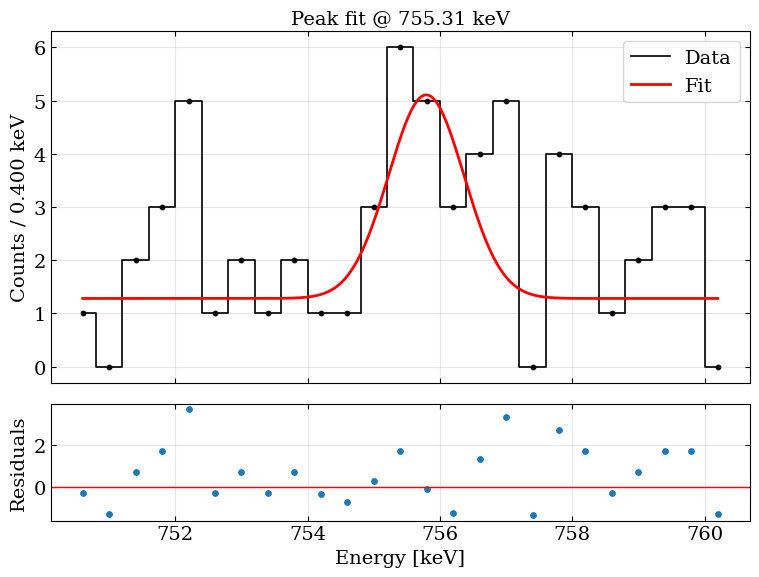

228Ac_755keV
{'type': 'single', 'mu': np.float64(755.7937523785183), 'sigma': np.float64(0.5685277039465729), 'FWHM': np.float64(1.3388827427941792), 'N': np.float64(5.452053724668042), 'B': np.float64(1.2798347506342114), 'err_mu': np.float64(0.2497278714043585), 'err_sigma': np.float64(0.23854774124452383), 'err_FWHM': np.float64(0.5617799306308536), 'err_N': np.float64(2.2277314090982125), 'err_B': np.float64(0.30231579404738007)}


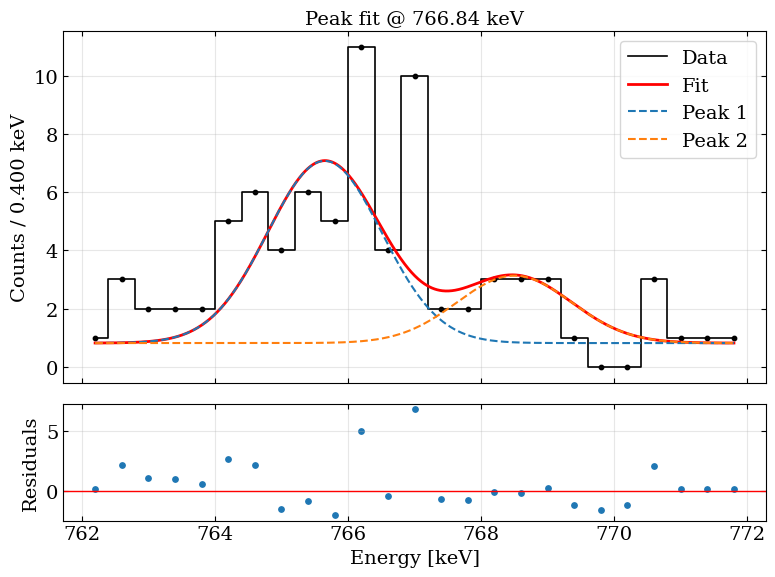

208Tl_766keV
{'type': 'double', 'mu1': np.float64(765.6498649576304), 'N1': np.float64(13.506346107218612), 'mu2': np.float64(768.5000000000001), 'N2': np.float64(5.000000000000001), 'sigma': np.float64(0.858453769170221), 'FWHM': np.float64(2.0216586263958702), 'B': np.float64(0.8093755932953798), 'err_mu1': np.float64(0.23438902993660268), 'err_N1': np.float64(3.467227117236937), 'err_mu2': np.float64(0.3898513998248199), 'err_N2': np.float64(2.1780006818686957), 'err_sigma': np.float64(0.19400432125482686), 'err_FWHM': np.float64(0.45688017655511726), 'err_B': np.float64(0.439247042347942)}


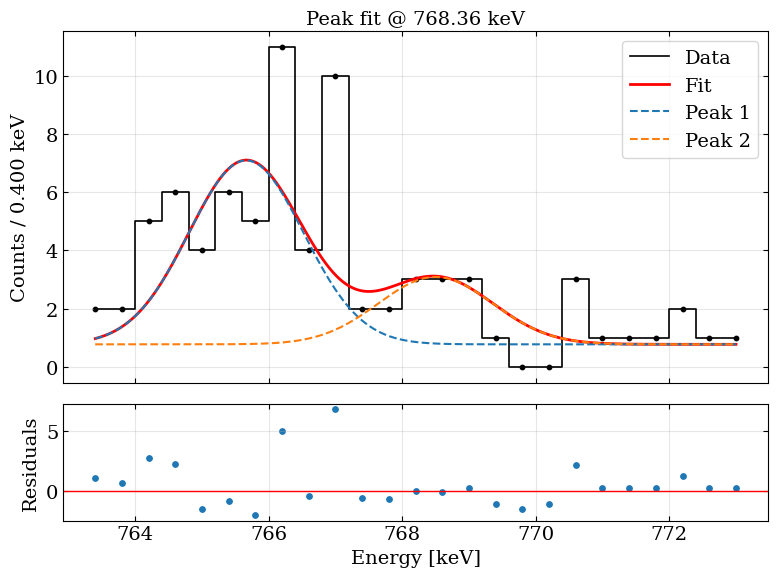

214_Bi
{'type': 'double', 'mu1': np.float64(765.6618051639873), 'N1': np.float64(13.647326786458459), 'mu2': np.float64(768.5000000000001), 'N2': np.float64(5.000000000000001), 'sigma': np.float64(0.8589462335763242), 'FWHM': np.float64(2.0228183800722435), 'B': np.float64(0.7659430778778463), 'err_mu1': np.float64(0.23224981038707762), 'err_N1': np.float64(3.3801703808036105), 'err_mu2': np.float64(0.38935444532375973), 'err_N2': np.float64(2.122777433473928), 'err_sigma': np.float64(0.18863001903749765), 'err_FWHM': np.float64(0.444223694833307), 'err_B': np.float64(0.40739568485184113)}


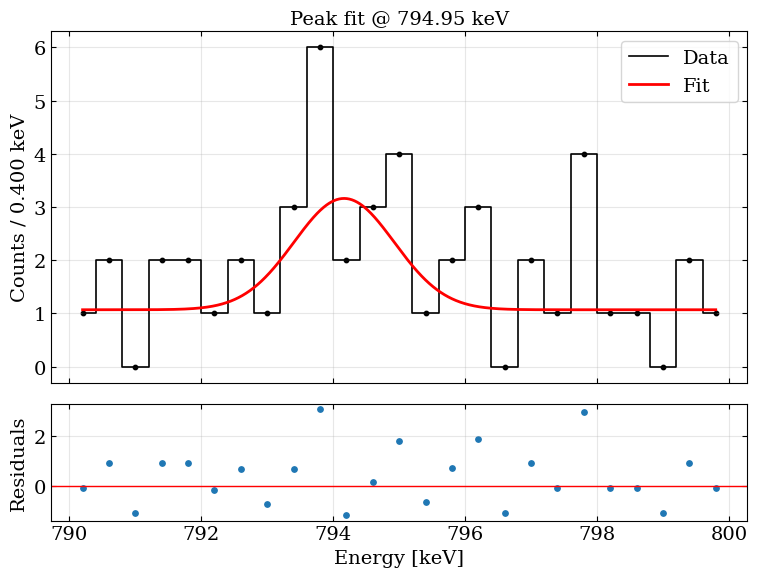

228Ac_794keV
{'type': 'single', 'mu': np.float64(794.1649260890495), 'sigma': np.float64(0.7604585042689673), 'FWHM': np.float64(1.790879777553418), 'N': np.float64(3.9877370361041153), 'B': np.float64(1.067521989937453), 'err_mu': np.float64(0.4076674799917075), 'err_sigma': np.float64(0.3821290022504343), 'err_FWHM': np.float64(0.8999138002997727), 'err_N': np.float64(2.1898673024145823), 'err_B': np.float64(0.29839888193846165)}


In [43]:
# ============================================================
# BACKGROUND PEAK FITS
# ============================================================
fit_results = {}

for peak_name, peak_energy in BACKGROUND_PEAKS.items():
    result = fit_peak(
        E_tot,
        Ntot,
        center=peak_energy,
        window=FIT_WINDOW,
        plot=True,
    )

    fit_results[peak_name] = result

    print("=" * 60)
    print(peak_name)
    print(result)

In [ ]:
print(double_results)

NameError: name 'double_results' is not defined

In [31]:
def build_results_double_peak(popt):

    mu1, N1, mu2, N2, sigma, B = popt

    results = {}

    # -----------------------------------
    # Peak 1 : 208Tl
    # -----------------------------------

    results["208Tl_766keV"] = {

        "mu": mu1,

        "sigma": sigma,

        "FWHM": 2.355 * sigma,

        "N_total": N1
    }

    # -----------------------------------
    # Peak 2 : 214Bi
    # -----------------------------------

    results["214_Bi"] = {

        "mu": mu2,

        "sigma": sigma,

        "FWHM": 2.355 * sigma,

        "N_total": N2
    }

    # -----------------------------------
    # Background
    # -----------------------------------

    results["background"] = {

        "offset": B
    }

    return results

NameError: name 'p0' is not defined

In [28]:
# ============================================================
# ROI SELECTION
# ============================================================
roi_mask = (
    (E_tot > SIGNAL["roi"][0])
    & (E_tot < SIGNAL["roi"][1])
)

E_roi = E_tot[roi_mask]
counts_roi = Ntot[roi_mask]

sigma_common = sigma_fun(E_roi.mean())
# ============================================================
# SIGNAL PDF
# ============================================================
mu_signal = SIGNAL["mu"]
sigma_signal = sigma_fun(mu_signal)

#PDF_signal = norm.pdf(E_roi, mu_signal, sigma_signal)
PDF_signal = norm.pdf(E_roi, mu_signal, sigma_common)

# ============================================================
# BACKGROUND PDFs
# ============================================================
background_names = list(BACKGROUND_PEAKS.keys())
background_energies = np.array(list(BACKGROUND_PEAKS.values()))
#background_sigmas = sigma_fun(background_energies)
background_sigmas = sigma_common
PDF_bg = np.array(
    [
        norm.pdf(E_roi, mu, sigma_common)
        for mu in background_energies
    ]
)


In [29]:
def get_effective_N(fit):
    if fit["model"] == "single":
        return fit["peaks"]["peak"]["N"]

    elif fit["model"] == "double":
        return (
            fit["peaks"]["peak1"]["N"] +
            fit["peaks"]["peak2"]["N"]
        )

In [30]:

# ============================================================
# BAYESIAN MODEL
# ============================================================
with pm.Model() as model:

    # ------------------------
    # Background peak priors
    # ------------------------
    A_bg = []
    mu_bg = []

    for peak_name in background_names:
        fit = fit_results[peak_name]

        A = pm.TruncatedNormal(
            f"A_{peak_name}",
            mu=fit["N"],
            sigma=max(fit["err_N"], 1.0),
            lower=0,
        )
        
        mu = pm.Normal(
        f"mu_{peak_name}",
        mu=fit["mu"],
        sigma=0.05  # o anche 0.05 keV se calibrazione buona
    )
        
        A_bg.append(A)
        mu_bg.append(mu)

    A_bg = pt.stack(A_bg)
    mu_bg = pt.stack(mu_bg)

    # ------------------------
    # Signal prior
    # ------------------------
    A_signal = pm.HalfNormal(
        "A_signal",
        sigma=500,
    )

    # ------------------------
    # Flat background prior
    # ------------------------
    Q = pm.HalfNormal(
        "Q",
        sigma=500,
    )
    

    # ------------------------
    # Expected counts
    # ------------------------
    lambda_E = (
        Q
        + pt.sum(A_bg[:, None] * PDF_bg, axis=0)
        + A_signal * PDF_signal
    )

    # Numerical stability
    lambda_E = pt.clip(lambda_E, 1e-9, np.inf)

    # ------------------------
    # Likelihood
    # ------------------------
    pm.Poisson(
        "counts_obs",
        mu=lambda_E,
        observed=counts_roi,
    )

    # ------------------------
    # Sampling
    # ------------------------
    trace = pm.sample(
        draws=SAMPLING_CONFIG["draws"],
        tune=SAMPLING_CONFIG["tune"],
        chains=SAMPLING_CONFIG["chains"],
        cores=min(4, multiprocessing.cpu_count()),
        target_accept=SAMPLING_CONFIG["target_accept"],
        init="jitter+adapt_diag",
        return_inferencedata=True,
        progressbar=True,
    )


# ============================================================
# SUMMARY
# ============================================================
summary = az.summary(trace, round_to=4)
print(summary)


KeyError: 'N'

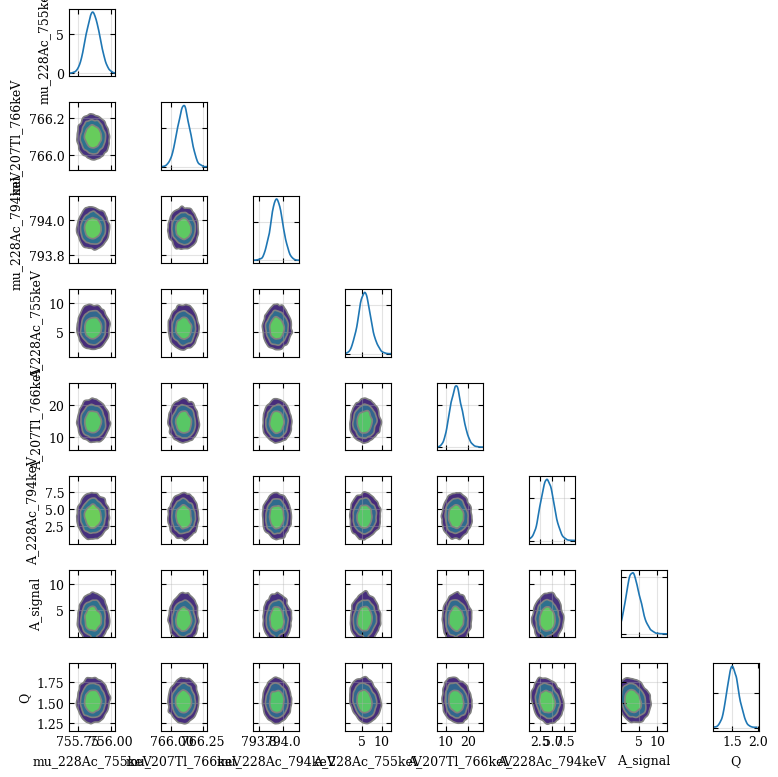

In [121]:

# ============================================================
# CORRELATION PLOTS
# ============================================================
axes = az.plot_pair(
    trace,
    kind="kde",
    marginals=True,
    figsize=(8, 8),
    textsize=9,
)

for ax in axes.flatten():
    ax.grid(alpha=0.35)

plt.tight_layout()
plt.show()


In [24]:


# ============================================================
# POSTERIOR OF SIGNAL
# ============================================================
signal_samples = trace.posterior["A_signal"].values.flatten()

N_signal_90 = np.percentile(signal_samples, 90)
N_signal_95 = np.percentile(signal_samples, 95)

print()
print("=" * 60)
print(f"90% upper limit on signal counts : {N_signal_90:.3f}")
print(f"95% upper limit on signal counts : {N_signal_95:.3f}")
print("=" * 60)


90% upper limit on signal counts : 6.084
95% upper limit on signal counts : 6.934


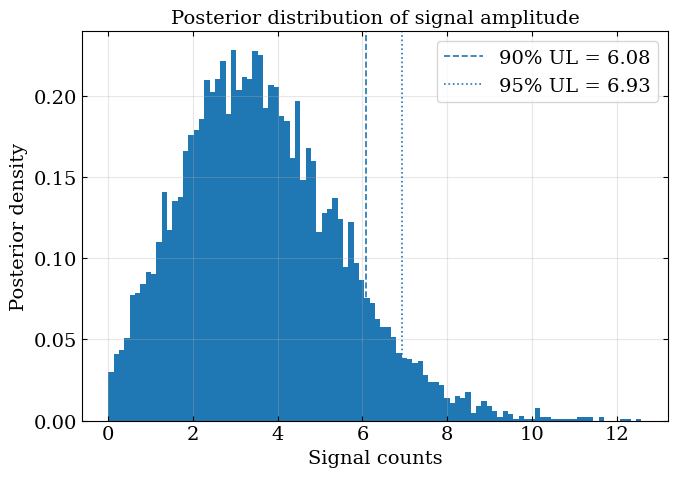

In [25]:
# ============================================================
# SIGNAL POSTERIOR PLOT
# ============================================================
plt.figure(figsize=(7, 5))

plt.hist(signal_samples, bins=100, density=True)

plt.axvline(
    N_signal_90,
    linestyle="--",
    label=f"90% UL = {N_signal_90:.2f}",
)

plt.axvline(
    N_signal_95,
    linestyle=":",
    label=f"95% UL = {N_signal_95:.2f}",
)

plt.xlabel("Signal counts")
plt.ylabel("Posterior density")
plt.title("Posterior distribution of signal amplitude")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()



In [26]:
posterior_means = {name: trace.posterior[name].mean().values for name in trace.posterior.data_vars}

print("Ampiezze medie dei picchi:")
for name, val in posterior_means.items():
    print(f"{name}: {val:.2f}")

Ampiezze medie dei picchi:
mu_228Ac_755keV: 755.86
mu_207Tl_766keV: 766.10
mu_228Ac_794keV: 793.95
A_228Ac_755keV: 5.71
A_207Tl_766keV: 14.79
A_228Ac_794keV: 3.95
A_signal: 3.65
Q: 1.52


In [27]:
background_names = list(BACKGROUND_PEAKS.keys())
background_energies = np.array(list(BACKGROUND_PEAKS.values()))
background_sigmas = sigma_fun(background_energies)


In [28]:
idata = trace
posterior = idata.posterior

# =========================
# POSTERIOR FLATTENING
# =========================
sigma_common = sigma_fun(E_roi.mean())
Q_s        = posterior["Q"].values.flatten()
A_signal_s = posterior["A_signal"].values.flatten()

A_bg_s = {
    name: posterior[f"A_{name}"].values.flatten()
    for name in background_names
}

# =========================
# COSTRUZIONE DI λ(E) PER OGNI SAMPLE
# =========================
lambda_samples = []
lambda_back = []

for i in range(len(Q_s)):
    lam = Q_s[i] * np.ones_like(E_roi)
    lam_bkg = Q_s[i] * np.ones_like(E_roi)
    for j, name in enumerate(background_names):
        lam += A_bg_s[name][i] * PDF_bg[j]   # PDF_bg deve avere stesso ordine di background_names
        lam_bkg += A_bg_s[name][i] * PDF_bg[j]
    lam += A_signal_s[i] * PDF_signal



    lambda_samples.append(lam)
    lambda_back.append(lam_bkg)

lambda_samples = np.array(lambda_samples)
lambda_back = np.array(lambda_back)
# =========================
# STATISTICHE POSTERIORI
# =========================
lambda_mean = np.mean(lambda_samples, axis=0)
lambda_low  = np.percentile(lambda_back, 5, axis=0)
lambda_high = np.percentile(lambda_back, 95, axis=0)

# =========================
# RICOSTRUZIONE DEL SOLO BACKGROUND
# =========================
posterior_means = {
    var: posterior[var].values.mean()
    for var in posterior.data_vars
}

lambda_pred_bkg = posterior_means['Q'] * np.ones_like(E_roi) 

for j, name in enumerate(background_names):
    lambda_pred_bkg += posterior_means[f"A_{name}"] * PDF_bg[j]

# =========================
# LIMITE 90% SUL SEGNALE
# =========================
N_signal_90 = np.percentile(A_signal_s, 90)
lambda_pred = lambda_pred_bkg + N_signal_90 * PDF_signal

# =========================
# RESIDUI
# =========================
residuals = counts_roi - lambda_mean


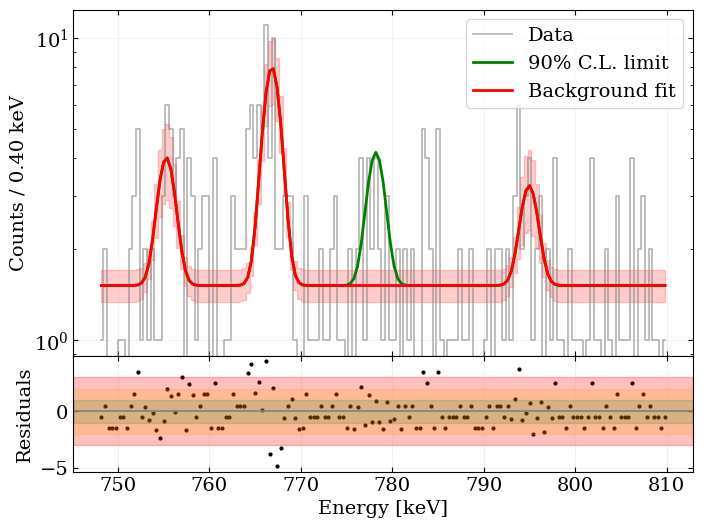

In [43]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    figsize=(8, 6)
)

# =========================
# PLOT SUPERIORE
# =========================
ax1.step(E_roi, counts_roi, where='mid', color='grey', alpha=0.6, label='Data')


ax1.plot(E_roi, lambda_pred, color='green', lw=2, label='90% C.L. limit')
ax1.plot(E_roi, lambda_pred_bkg, color='red', lw=2, label='Background fit')

ax1.fill_between(E_roi, lambda_low, lambda_high,
                 color='red', alpha=0.2, step='mid')

ax1.set_yscale('log')
ax1.set_ylabel(f"Counts / {E_roi[1]-E_roi[0]:.2f} keV")
ax1.grid(alpha=0.15)
ax1.legend()


# =========================
# PLOT INFERIORE (RESIDUI)
# =========================
ax2.scatter(E_roi, residuals, s=4, color='black')


ax2.axhspan(-3, 3, color='red', alpha=0.25)
ax2.axhspan(-2, 2, color='orange', alpha=0.2)
ax2.axhspan(-1, 1, color='green', alpha=0.15)


ax2.axhline(0, color='gray')
ax2.set_xlabel("Energy [keV]")
ax2.set_ylabel("Residuals")
ax2.grid(alpha=0.2)
plt.subplots_adjust(hspace=0)
plt.show()


In [46]:

# Dati campione
m_sample = 551.3        # massa ZrO2 in grammi
Mr_sample = 123.22      # massa molare ZrO2 [g/mol]
N_A = 6.022e23          # numero di Avogadro
eff_96Zr = 0.024131  # efficienza di rivelazione
i_a_96Zr = 0.028       # abbondanza isotopica
t_live =  t_tot/(60*60*24*365)             # 50 giorni in anni

# Posterior del numero di eventi segnale
signal_samples = trace.posterior['A_signal'].values.flatten()

# Numero di nuclei 96Zr nel campione
N_nuclei = (m_sample * i_a_96Zr / Mr_sample) * N_A

percentile = 90

T_half_limit = (np.log(2) * N_nuclei * eff_96Zr * t_live) / np.percentile(signal_samples, percentile)
print(f"T1/2 > {T_half_limit:.2e} yrs at {percentile}%")

T1/2 > 4.63e+19 yrs at 90%


In [81]:
m_sample* i_a_96Zr * 0.024131 * 0.001 * ( t_tot/(60*60) )

0.7353735925888651

# picco centrale

In [62]:
ENERGY_RANGE = (0, 3000)
BIN_WIDTH = 0.4

BACKGROUND_PEAKS = {
    "208-Tl" :583.19,
    "208-Tl+ann" :511,
    #"EC-Sr" : 514

}


FIT_WINDOW = 5

SIGNAL = {
    "mu": 551.8,
    "roi": (551.8-50, 551.8+50),
}

SAMPLING_CONFIG = {
    "draws": 2000,
    "tune": 2000,
    "chains": 4,
    "target_accept": 0.95,
}


In [63]:
def double_gaussian_plus_bg(E, mu1, sigma1, N1, mu2, sigma2, N2, M, B):
    g1 = N1 * np.exp(-(E - mu1)**2 / (2 * sigma1**2)) / (sigma1 * np.sqrt(2*np.pi))
    g2 = N2 * np.exp(-(E - mu2)**2 / (2 * sigma2**2)) / (sigma2 * np.sqrt(2*np.pi))
    return g1 + g2 + M * E + B

In [64]:
'''def fit_peak(E, counts, center, window=4, plot=True):

    mask = (E > center - window) & (E < center + window)

    E_roi = E[mask]
    counts_roi = counts[mask]

    sigma_guess = sigma_fun(center)

    # ============================================================
    # CASE 1: DOUBLE PEAK REGION (505–520 keV)
    # ============================================================
    if 505 <= center <= 520:

        mu1_guess = 511.0
        mu2_guess = 514.0

        p0 = [
            mu1_guess,
            sigma_guess,
            np.sum(counts_roi) * 0.6,
            mu2_guess,
            sigma_guess,
            np.sum(counts_roi) * 0.4,
            0,
            np.median(counts_roi),
        ]

        bounds = (
            [509, 0.01, 0, 512, 0.01, 0, -np.inf, 0],
            [513, 10, np.inf, 516, 10, np.inf, np.inf, np.inf],
        )

        popt, pcov = curve_fit(
            double_gaussian_plus_bg,
            E_roi,
            counts_roi,
            p0=p0,
            bounds=bounds,
            maxfev=20000,
        )

        perr = np.sqrt(np.diag(pcov))

        result = {
            "mu1": popt[0],
            "sigma1": popt[1],
            "N1": popt[2],
            "mu2": popt[3],
            "sigma2": popt[4],
            "N2": popt[5],
            "M": popt[6],
            "B": popt[7],
        }

        model_fun = lambda x: double_gaussian_plus_bg(x, *popt)

    # ============================================================
    # CASE 2: SINGLE PEAK (DEFAULT)
    # ============================================================
    else:

        p0 = [
            center,
            sigma_guess,
            np.sum(counts_roi),
            0,
            np.median(counts_roi),
        ]

        bounds = (
            [center - 1, 0.01, 0, -np.inf, 0],
            [center + 1, 10, np.inf, np.inf, np.inf],
        )

        popt, pcov = curve_fit(
            gaussian_plus_bg,
            E_roi,
            counts_roi,
            p0=p0,
            bounds=bounds,
            maxfev=10000,
        )

        perr = np.sqrt(np.diag(pcov))

        result = {
            "mu": popt[0],
            "sigma": popt[1],
            "N": popt[2],
            "M": popt[3],
            "B": popt[4],
            "err_mu": perr[0],
            "err_sigma": perr[1],
            "err_N": perr[2],
            "err_M": perr[3],
            "err_B": perr[4],
        }

        model_fun = lambda x: gaussian_plus_bg(x, *popt)

    # ============================================================
    # PLOT (UNIFIED)
    # ============================================================

    if plot:
        fig, ax = plt.subplots(2, 1, figsize=(7, 6),
                               sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})

        E_fit = np.linspace(E_roi.min(), E_roi.max(), 500)
        model_fit = model_fun(E_fit)

        ax[0].step(E_roi, counts_roi, where="mid", color="black")
        ax[0].scatter(E_roi, counts_roi, color="black", s=10)
        ax[0].plot(E_fit, model_fit, color="red", lw=2)

        ax[0].set_ylabel(f"Counts / {E_roi[1]-E_roi[0]:.2f} keV")
        ax[0].set_title(f"Peak @ {center:.2f} keV")
        ax[0].grid(alpha=0.3)

        residuals = counts_roi - model_fun(E_roi)

        ax[1].scatter(E_roi, residuals, s=15)
        ax[1].axhline(0, color="red")
        ax[1].set_xlabel("Energy [keV]")
        ax[1].set_ylabel("Residuals")
        ax[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return result'''

'def fit_peak(E, counts, center, window=4, plot=True):\n\n    mask = (E > center - window) & (E < center + window)\n\n    E_roi = E[mask]\n    counts_roi = counts[mask]\n\n    sigma_guess = sigma_fun(center)\n\n    # ============================================================\n    # CASE 1: DOUBLE PEAK REGION (505–520 keV)\n    # ============================================================\n    if 505 <= center <= 520:\n\n        mu1_guess = 511.0\n        mu2_guess = 514.0\n\n        p0 = [\n            mu1_guess,\n            sigma_guess,\n            np.sum(counts_roi) * 0.6,\n            mu2_guess,\n            sigma_guess,\n            np.sum(counts_roi) * 0.4,\n            0,\n            np.median(counts_roi),\n        ]\n\n        bounds = (\n            [509, 0.01, 0, 512, 0.01, 0, -np.inf, 0],\n            [513, 10, np.inf, 516, 10, np.inf, np.inf, np.inf],\n        )\n\n        popt, pcov = curve_fit(\n            double_gaussian_plus_bg,\n            E_roi,\n            co

In [65]:
def build_results_double_peak(popt):
    mu1, sigma1, N1, mu2, sigma2, N2, M, B = popt

    results = {}

    # ---------------------------
    # Peak 511 (ann + Tl-208)
    # ---------------------------
    results["511_keV"] = {
        "mu": mu1,
        "sigma": sigma1,
        "N_total": N1,
        "components": {
            "annihilation + Tl-208": N1
        }
    }

    # ---------------------------
    # Peak 514 (Sr)
    # ---------------------------
    results["514_keV"] = {
        "mu": mu2,
        "sigma": sigma2,
        "N_Sr": N2
    }

    # ---------------------------
    # Background
    # ---------------------------
    results["background"] = {
        "slope": M,
        "offset": B
    }

    return results

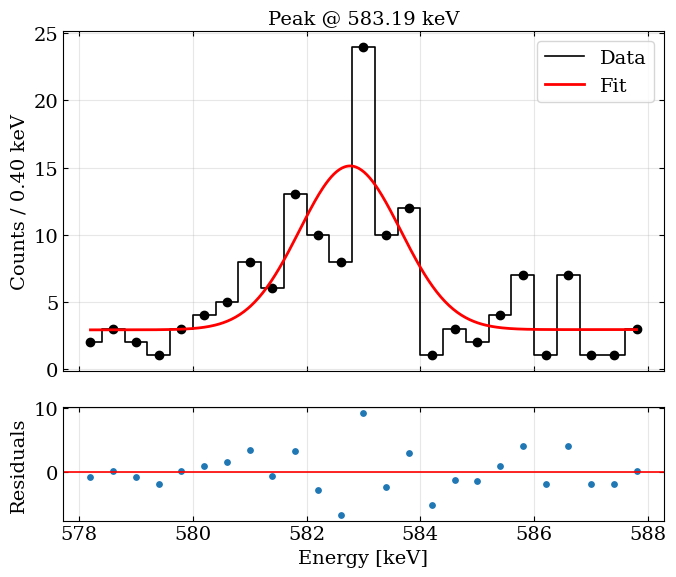

208-Tl
{'model': 'single', 'peaks': {'peak': {'mu': np.float64(582.763796158874), 'sigma': np.float64(0.8894889157166151), 'N': np.float64(27.20654698060362), 'assignment': '208-Tl'}}, 'background': {'M': np.float64(0.002238252200867003), 'B': np.float64(1.614444374692065)}}


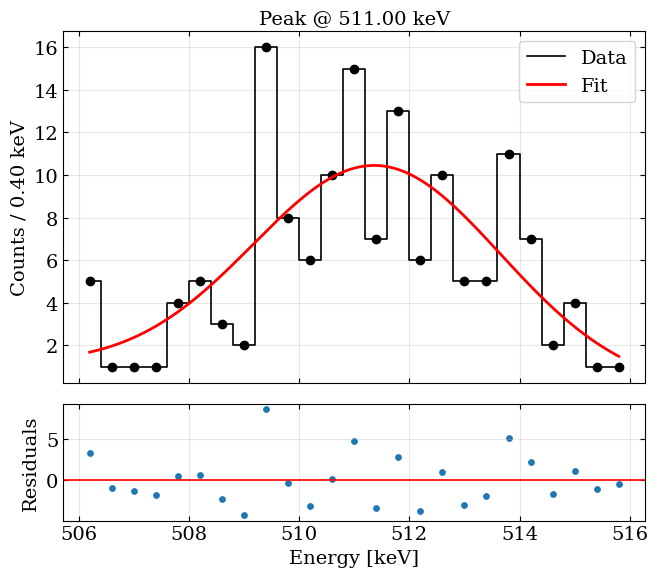

208-Tl+ann
{'model': 'single', 'peaks': {'peak': {'mu': np.float64(511.41197885907945), 'sigma': np.float64(2.2418570495658736), 'N': np.float64(56.08789224288639), 'assignment': '208-Tl+ann'}}, 'background': {'M': np.float64(-0.10349949022867913), 'B': np.float64(53.39670835875626)}}


In [67]:
fit_results = {}
des = [5,5,5.5]

for (peak_name, peak_energy), de in zip(BACKGROUND_PEAKS.items(),des):

    result = fit_peak(
        E_tot,
        Ntot,
        center=peak_energy,
        window=de,
        plot=True,
    )

    # ==============================
    # WRAP OUTPUT STANDARDIZATION
    # ==============================
    if "mu1" in result:  # double gaussian case

        fit_results[peak_name] = {
            "model": "double",
            "peaks": {
                "peak1": {
                    "mu": result["mu1"],
                    "sigma": result["sigma1"],
                    "N": result["N1"],
                    "assignment": "511 keV (ann + Tl-208)"
                },
                "peak2": {
                    "mu": result["mu2"],
                    "sigma": result["sigma2"],
                    "N": result["N2"],
                    "assignment": "514 keV (Sr)"
                }
            },
            "background": {
                "M": result["M"],
                "B": result["B"],
            }
        }

    else:  # single gaussian case

        fit_results[peak_name] = {
            "model": "single",
            "peaks": {
                "peak": {
                    "mu": result["mu"],
                    "sigma": result["sigma"],
                    "N": result["N"],
                    "assignment": peak_name
                }
            },
            "background": {
                "M": result["M"],
                "B": result["B"],
            }
        }

    print("=" * 60)
    print(peak_name)
    print(fit_results[peak_name])

In [68]:
# ============================================================
# ROI SELECTION
# ============================================================
roi_mask = (
    (E_tot > SIGNAL["roi"][0])
    & (E_tot < SIGNAL["roi"][1])
)

E_roi = E_tot[roi_mask]
counts_roi = Ntot[roi_mask]

sigma_common = sigma_fun(E_roi.mean())
# ============================================================
# SIGNAL PDF
# ============================================================
mu_signal = SIGNAL["mu"]
sigma_signal = sigma_fun(mu_signal)

#PDF_signal = norm.pdf(E_roi, mu_signal, sigma_signal)
PDF_signal = norm.pdf(E_roi, mu_signal, sigma_common)

# ============================================================
# BACKGROUND PDFs
# ============================================================
background_names = list(BACKGROUND_PEAKS.keys())
background_energies = np.array(list(BACKGROUND_PEAKS.values()))
#background_sigmas = sigma_fun(background_energies)
background_sigmas = sigma_common
PDF_bg = np.array(
    [
        norm.pdf(E_roi, mu, sigma_common)
        for mu in background_energies
    ]
)


In [69]:
def get_effective_N(fit):
    if fit["model"] == "single":
        return fit["peaks"]["peak"]["N"]

    elif fit["model"] == "double":
        return (
            fit["peaks"]["peak1"]["N"] +
            fit["peaks"]["peak2"]["N"]
        )

In [70]:
with pm.Model() as model:

    # ============================================================
    # BACKGROUND PEAK PRIORS
    # ============================================================
    A_bg = []

    for peak_name in background_names:

        fit = fit_results[peak_name]

        A = pm.TruncatedNormal(
            f"A_{peak_name}",
            mu=get_effective_N(fit),
            sigma=max(
                fit["peaks"]["peak"]["sigma"] if fit["model"] == "single"
                else fit["peaks"]["peak1"]["sigma"],
                1.0
            ),
            lower=0,
        )

        A_bg.append(A)

    A_bg = pt.stack(A_bg)
    mu_bg = []

    for peak_name in background_names:

        fit = fit_results[peak_name]

        mu = pm.Normal(
            f"mu_{peak_name}",
            mu=fit["peaks"]["peak"]["mu"] if fit["model"] == "single"
            else fit["peaks"]["peak1"]["mu"],
            sigma=max(
                fit["peaks"]["peak"]["sigma"] if fit["model"] == "single"
                else fit["peaks"]["peak1"]["sigma"],
                1.0
            )
        )

        mu_bg.append(mu)

    mu_bg = pt.stack(mu_bg)


    # ============================================================
    # SIGNAL
    # ============================================================
    A_signal = pm.HalfNormal(
        "A_signal",
        sigma=500,
    )

    # ============================================================
    # FLAT BACKGROUND
    # ============================================================
    Q = pm.HalfNormal(
        "Q",
        sigma=500,
    )

    # ============================================================
    # EXPECTED COUNTS MODEL
    # ============================================================
    lambda_E = (
        Q
        + pt.sum(A_bg[:, None] * PDF_bg, axis=0)
        + A_signal * PDF_signal
    )

    lambda_E = pt.clip(lambda_E, 1e-9, np.inf)

    # ============================================================
    # LIKELIHOOD
    # ============================================================
    pm.Poisson(
        "counts_obs",
        mu=lambda_E,
        observed=counts_roi,
    )

    # ============================================================
    # SAMPLING
    # ============================================================
    trace = pm.sample(
        draws=SAMPLING_CONFIG["draws"],
        tune=SAMPLING_CONFIG["tune"],
        chains=SAMPLING_CONFIG["chains"],
        cores=min(4, multiprocessing.cpu_count()),
        target_accept=SAMPLING_CONFIG["target_accept"],
        init="jitter+adapt_diag",
        return_inferencedata=True,
        progressbar=True,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A_208-Tl, A_208-Tl+ann, mu_208-Tl, mu_208-Tl+ann, A_signal, Q]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 4 seconds.


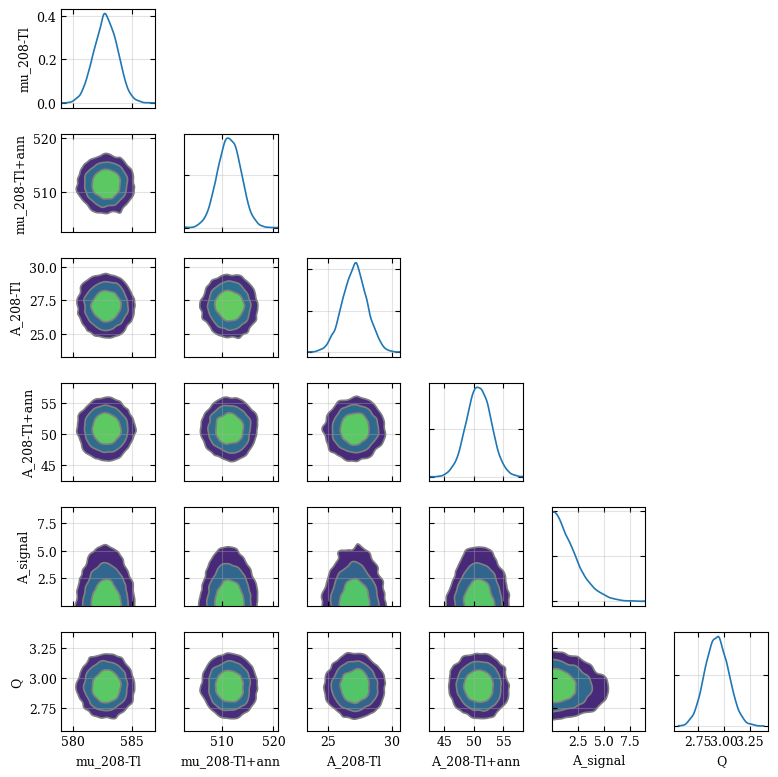

In [71]:

# ============================================================
# CORRELATION PLOTS
# ============================================================
axes = az.plot_pair(
    trace,
    kind="kde",
    marginals=True,
    figsize=(8, 8),
    textsize=9,
)

for ax in axes.flatten():
    ax.grid(alpha=0.35)

plt.tight_layout()
plt.show()


In [72]:


# ============================================================
# POSTERIOR OF SIGNAL
# ============================================================
signal_samples = trace.posterior["A_signal"].values.flatten()

N_signal_90 = np.percentile(signal_samples, 90)
N_signal_95 = np.percentile(signal_samples, 95)

print()
print("=" * 60)
print(f"90% upper limit on signal counts : {N_signal_90:.3f}")
print(f"95% upper limit on signal counts : {N_signal_95:.3f}")
print("=" * 60)


90% upper limit on signal counts : 3.601
95% upper limit on signal counts : 4.439


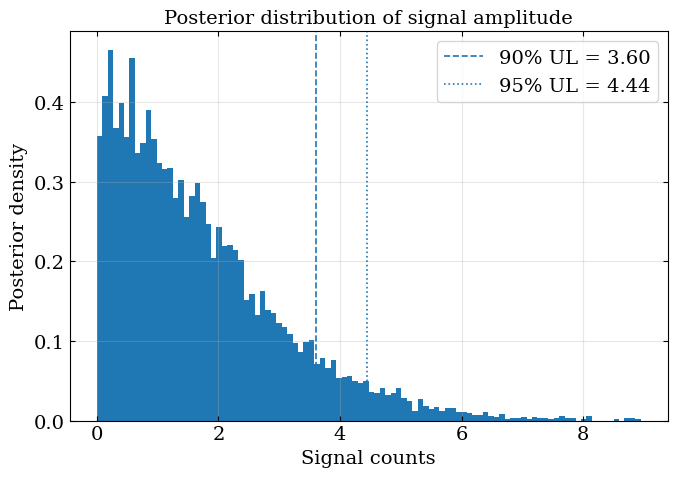

In [73]:
# ============================================================
# SIGNAL POSTERIOR PLOT
# ============================================================
plt.figure(figsize=(7, 5))

plt.hist(signal_samples, bins=100, density=True)

plt.axvline(
    N_signal_90,
    linestyle="--",
    label=f"90% UL = {N_signal_90:.2f}",
)

plt.axvline(
    N_signal_95,
    linestyle=":",
    label=f"95% UL = {N_signal_95:.2f}",
)

plt.xlabel("Signal counts")
plt.ylabel("Posterior density")
plt.title("Posterior distribution of signal amplitude")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()




In [74]:
posterior_means = {name: trace.posterior[name].mean().values for name in trace.posterior.data_vars}

print("Ampiezze medie dei picchi:")
for name, val in posterior_means.items():
    print(f"{name}: {val:.2f}")

Ampiezze medie dei picchi:
mu_208-Tl: 582.76
mu_208-Tl+ann: 511.37
A_208-Tl: 27.04
A_208-Tl+ann: 50.80
A_signal: 1.70
Q: 2.93


In [75]:
background_names = list(BACKGROUND_PEAKS.keys())
background_energies = np.array(list(BACKGROUND_PEAKS.values()))
background_sigmas = sigma_fun(background_energies)


In [76]:
idata = trace
posterior = idata.posterior

# =========================
# POSTERIOR FLATTENING
# =========================
sigma_common = sigma_fun(E_roi.mean())
Q_s        = posterior["Q"].values.flatten()
A_signal_s = posterior["A_signal"].values.flatten()

A_bg_s = {
    name: posterior[f"A_{name}"].values.flatten()
    for name in background_names
}

# =========================
# COSTRUZIONE DI λ(E) PER OGNI SAMPLE
# =========================
lambda_samples = []
lambda_back = []

for i in range(len(Q_s)):
    lam = Q_s[i] * np.ones_like(E_roi)
    lam_bkg = Q_s[i] * np.ones_like(E_roi)
    for j, name in enumerate(background_names):
        lam += A_bg_s[name][i] * PDF_bg[j]   # PDF_bg deve avere stesso ordine di background_names
        lam_bkg += A_bg_s[name][i] * PDF_bg[j]
    lam += A_signal_s[i] * PDF_signal



    lambda_samples.append(lam)
    lambda_back.append(lam_bkg)

lambda_samples = np.array(lambda_samples)
lambda_back = np.array(lambda_back)
# =========================
# STATISTICHE POSTERIORI
# =========================
lambda_mean = np.mean(lambda_samples, axis=0)
lambda_low  = np.percentile(lambda_back, 5, axis=0)
lambda_high = np.percentile(lambda_back, 95, axis=0)

# =========================
# RICOSTRUZIONE DEL SOLO BACKGROUND
# =========================
posterior_means = {
    var: posterior[var].values.mean()
    for var in posterior.data_vars
}

lambda_pred_bkg = posterior_means['Q'] * np.ones_like(E_roi) 

for j, name in enumerate(background_names):
    lambda_pred_bkg += posterior_means[f"A_{name}"] * PDF_bg[j]

# =========================
# LIMITE 90% SUL SEGNALE
# =========================
N_signal_90 = np.percentile(A_signal_s, 90)
lambda_pred = lambda_pred_bkg + N_signal_90 * PDF_signal

# =========================
# RESIDUI
# =========================
residuals = counts_roi - lambda_mean


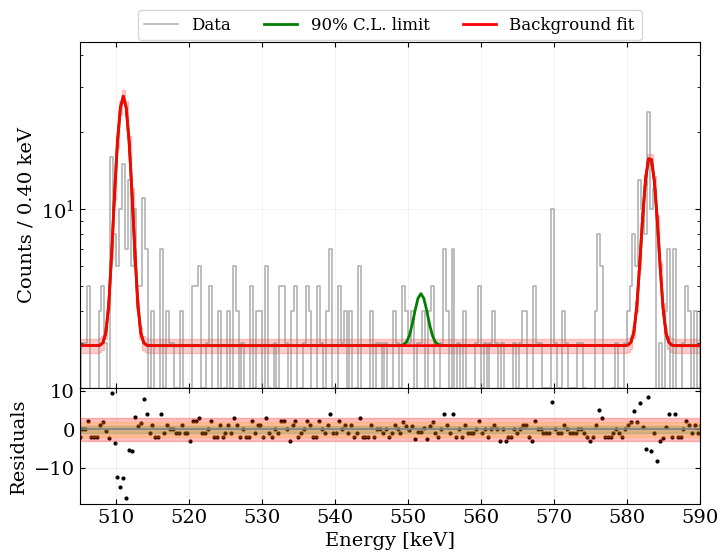

In [80]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    figsize=(8, 6)
)

# =========================
# PLOT SUPERIORE
# =========================
ax1.step(E_roi, counts_roi, where='mid', color='grey', alpha=0.6, label='Data')


ax1.plot(E_roi, lambda_pred, color='green', lw=2, label='90% C.L. limit')
ax1.plot(E_roi, lambda_pred_bkg, color='red', lw=2, label='Background fit')

ax1.fill_between(E_roi, lambda_low, lambda_high,
                 color='red', alpha=0.2, step='mid')

ax1.set_yscale('log')
ax1.set_ylim(2, 45)
ax1.set_ylabel(f"Counts / {E_roi[1]-E_roi[0]:.2f} keV")
ax1.grid(alpha=0.15)
ax1.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    fontsize=12
)


# =========================
# PLOT INFERIORE (RESIDUI)
# =========================
ax2.scatter(E_roi, residuals, s=4, color='black')


ax2.axhspan(-3, 3, color='red', alpha=0.25)
ax2.axhspan(-2, 2, color='orange', alpha=0.2)
ax2.axhspan(-1, 1, color='green', alpha=0.15)


ax2.axhline(0, color='gray')
ax2.set_xlabel("Energy [keV]")
ax2.set_ylabel("Residuals")
ax2.grid(alpha=0.2)
plt.xlim(505,590)
plt.subplots_adjust(hspace=0)
plt.show()


In [93]:
# Gamma eval

eff_3peak = 0.0333
eff_96Zr = 0.024131 
# Numero di nuclei 96Zr nel campione
N_nuclei = (m_sample * i_a_96Zr / Mr_sample) * N_A

signal_samples = np.percentile(trace.posterior['A_signal'].values.flatten(), percentile)
signal_samples =  3.557
G_oeak3 = signal_samples / (  N_nuclei * eff_96Zr * t_live )


In [94]:
T = np.log(2) / G_oeak3

In [95]:
T

np.float64(7.99475329408952e+19)